# DeepSeek-Foundations

### Technical Report · The Mathematical Foundations of Modern Machine Learning (LLM Edition)

**Release:** v1.0 · **Date:** August 2026 · **Format:** Google Colab notebooks · **License:** MIT
**Series:** 1 master report + 7 workbooks · **Runtime:** every cell in this notebook runs in under ~2 minutes on a free CPU runtime

---

> **Abstract.** We introduce **DeepSeek-Foundations**, an open, self-contained curriculum for the mathematics that underpin modern machine learning, with a direct line of sight to the transformer models behind today's large language models. The curriculum is a series of seven workbooks plus this master report. Each workbook isolates one pillar of the foundation — linear algebra, calculus and automatic differentiation, probability and statistics, information theory, optimization, neural networks, and the transformer itself — and every workbook follows one rule: **each equation is followed by executable NumPy code**. This master notebook is the "paper": it states the central claim, walks each pillar in a single sitting, and closes with a **main result** — a complete from-scratch NumPy implementation of a tiny GPT, trained end-to-end with manually derived backpropagation, gradient-checked against finite differences, with measured loss, perplexity, and generated text.

**The central claim.** An LLM is a differentiable function that maps a sequence of tokens to a probability distribution over the next token, trained by gradient descent on cross-entropy. Everything else — architectures, data pipelines, quantization, KV caches, mixture-of-experts, RLHF — is engineering that makes this one mechanism faster, larger, cheaper, or better aligned.

**We encourage you to open the workbooks as topics appear.** Each takes 45–90 minutes and assumes nothing beyond high-school math and curiosity.

## 1. Introduction

**Why the math?** Every fluent paragraph an LLM has ever produced is the consequence of a small set of mathematical objects composed at scale:

| Object | Where it lives in an LLM |
|---|---|
| Vectors & matrices | every embedding, every weight, every attention score |
| The gradient & chain rule | backpropagation — how the model learns at all |
| Probability | the output layer is a probability distribution over tokens |
| Information theory | the loss function *is* cross-entropy; perplexity *is* its exponential |
| Optimization | AdamW + schedules — how the loss is actually driven down |
| The transformer | the composition that makes all of the above work on sequences |

**The master equation.** Write $x_{<t}$ for the tokens seen so far. An LLM is a function $f_\theta$ with parameters $\theta$ that outputs a probability distribution over the next token:

$$p_\theta(x_{t+1} \mid x_{<t}) = \mathrm{softmax}\big(W_{\text{out}}\, h_t\big)$$

where $h_t$ is the hidden state produced by the transformer stack. Training minimizes the **cross-entropy** of the model's predictions against the data:

$$\mathcal{L}(\theta) = -\mathbb{E}_{(x_{<t},\, x_{t+1}) \sim \text{data}}\big[\log p_\theta(x_{t+1} \mid x_{<t})\big]$$

and "learning" is gradient descent on $\mathcal{L}$ with respect to $\theta$, where every gradient is computed by the **chain rule** applied in reverse — backpropagation. If you can see why each of those symbols is doing what it does, you hold the foundation. This notebook walks each symbol in turn, then proves the whole thing works by training a real (tiny) GPT in pure NumPy.

**How to use this curriculum.** Read this master notebook top to bottom first. Whenever a section links a workbook, that is your cue to *stop and go deeper* — the workbook is the full treatment, this notebook is the map. Suggested cadence: one pillar per sitting (30–40 minutes), workbooks on the days in between. Mastery is not finishing the notebooks; it is closing the notebook and re-deriving the key equations from memory.

## 2. The Release: One Paper, Seven Workbooks

| # | Pillar | What you will master | Time |
|---|---|---|---|
| 01 | [Linear Algebra](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/01_Linear_Algebra.ipynb) | vectors, matrices, eigendecomposition, SVD — embeddings, LoRA, quantization | 60 min |
| 02 | [Calculus & Autodiff](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/02_Calculus_and_Autodiff.ipynb) | gradients, chain rule, backprop, automatic differentiation | 75 min |
| 03 | [Probability & Statistics](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/03_Probability_and_Statistics.ipynb) | distributions, Bayes, MLE — the model as a distribution over tokens | 75 min |
| 04 | [Information Theory](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/04_Information_Theory.ipynb) | entropy, cross-entropy, KL divergence, perplexity — the loss function itself | 60 min |
| 05 | [Optimization](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/05_Optimization.ipynb) | gradient descent, SGD, momentum, Adam, learning-rate schedules | 75 min |
| 06 | [Neural Networks](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/06_Neural_Networks.ipynb) | MLPs, backprop from scratch, initialization, regularization | 90 min |
| 07 | [The Transformer](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/07_Transformers.ipynb) | attention, QKV, positional encoding, multi-head, scaling laws | 90 min |

**Prerequisites.** None beyond high-school algebra and a working `import numpy`. Each workbook opens with its own refresher and each exercise has a solution.

**The papers ladder.** This curriculum exists so that frontier papers become readable cold. The natural next rungs: Vaswani et al. 2017 (*Attention Is All You Need*) → RoPE → FlashAttention → LoRA → DeepSeek-V2 (MLA) → DeepSeek-V3 (MoE + FP8) → DeepSeek-R1 (RL reasoning). Every one of them is standard transformer math plus well-documented engineering.

## 3.1 Pillar I — Linear Algebra: where all data lives

Every input, every weight, every intermediate value in an LLM is a **tensor** — a multidimensional array. A token is a vector (its embedding); a sentence is a matrix; a batch of sentences is a 3-D tensor. Three ideas carry almost all of deep learning:

1. **The dot product measures alignment.** $\langle a, b \rangle = \sum_i a_i b_i$. Two embedding vectors pointing in similar directions (cosine similarity near 1) mean "related concepts". Attention scores *are* dot products.
2. **Matrices are linear maps.** Multiplying a vector by a weight matrix $W$ rotates, scales, and projects it. A neural-network layer is literally $h = xW + b$ — a linear map followed by a nonlinearity. Depth = composing many such maps.
3. **Eigendecomposition and SVD factor matrices into understandable pieces.** The singular value decomposition $A = U\Sigma V^\top$ tells you the "directions of importance" of any matrix. Truncating $\Sigma$ gives the best low-rank approximation — which is exactly the trick behind **LoRA** (fine-tune a low-rank correction) and the intuition behind **quantization** (keep only the important structure).

**→ Open ["Workbook 01 — Linear Algebra"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/01_Linear_Algebra.ipynb) for the full treatment.** Here is the demo:

In [1]:

import numpy as np
rng = np.random.default_rng(0)

# (1) Embeddings as vectors: cosine similarity = semantic relatedness
rng = np.random.default_rng(0)
base = rng.normal(size=8)                                   # shared "royalty" subspace
king  = base + rng.normal(size=8) * 0.15
queen = base + rng.normal(size=8) * 0.15
banana = rng.normal(size=8)
def cos(a, b): return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
print(f"cos(king, queen)  = {cos(king, queen):+.3f}   (related words -> similar direction)")
print(f"cos(king, banana) = {cos(king, banana):+.3f}   (unrelated words -> near zero)")

# (2) Attention is a weighted average: a 3-token context mixes embeddings
W = np.array([[0.7, 0.2, 0.1]])
print("context vector   :", (W @ np.stack([king, queen, banana])).round(3))

# (3) SVD low-rank approximation: truncating Sigma = the LoRA / compression intuition
A = rng.normal(size=(40, 40))
U, S, Vt = np.linalg.svd(A)
for r in (1, 5, 20):
    Ar = (U[:, :r] * S[:r]) @ Vt[:r, :]
    print(f"rank-{r:2d} approx of 40x40: rel. error {np.linalg.norm(A - Ar) / np.linalg.norm(A):.3f}")


cos(king, queen)  = +0.963   (related words -> similar direction)
cos(king, banana) = -0.396   (unrelated words -> near zero)
context vector   : [[ 0.113 -0.252  0.449  0.038 -0.776  0.365  0.922  0.765]]
rank- 1 approx of 40x40: rel. error 0.947
rank- 5 approx of 40x40: rel. error 0.777
rank-20 approx of 40x40: rel. error 0.305


## 3.2 Pillar II — Calculus & Automatic Differentiation: how learning happens

Training is: change the parameters so the loss goes *down*. The engine of that change is the **gradient** — the vector of partial derivatives $\nabla_\theta \mathcal{L}$, which points in the direction of steepest *ascent* (so we step the opposite way). Two facts do all the work:

1. **The gradient is computed with the chain rule, applied in reverse.** The loss is a composition of hundreds of differentiable functions (each layer, each softmax, each norm). The derivative of a composition is a product of derivatives — and computing that product from the *output* back to the *inputs* (reverse mode) is exactly **backpropagation**. It reuses one forward pass's worth of computation, which is why training deep networks is even possible.
2. **Automatic differentiation is not symbolic math and not numerical approximation — it is the chain rule, applied to numbers.** Every deep-learning framework (PyTorch, JAX, TensorFlow) is a machine for doing reverse-mode autodiff. When you write `loss.backward()`, this is what runs.

**→ Open ["Workbook 02 — Calculus & Autodiff"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/02_Calculus_and_Autodiff.ipynb)** — including building a tiny autodiff engine from scratch. Demo:

In [2]:

def f(x): return x ** 2
def df(x): return 2 * x                       # analytic derivative
def num_diff(f, x, h=1e-6): return (f(x + h) - f(x - h)) / (2 * h)   # numeric

for x in (1.0, 3.0):
    print(f"x={x}: analytic {df(x):+.6f}   numeric {num_diff(f, x):+.6f}")

# The chain rule: d/dx sin(x^2) = cos(x^2) * 2x  -- backprop is this, composed 100s of times
x = 1.3
print(f"chain rule: analytic {np.cos(x**2) * 2 * x:+.6f}   numeric {num_diff(lambda t: np.sin(t**2), x):+.6f}")


x=1.0: analytic +2.000000   numeric +2.000000
x=3.0: analytic +6.000000   numeric +6.000000
chain rule: analytic -0.309196   numeric -0.309196


## 3.3 Pillar III — Probability & Statistics: what the model is

The output of an LLM is not "the next word" — it is a **probability distribution over the vocabulary**. Sampling from it is how you get text; taking its maximum is greedy decoding; the whole model is a machine for estimating conditional probabilities

$$p_\theta(x_{t+1} \mid x_{<t}).$$

Three ideas matter most:

1. **The categorical distribution is the output layer.** $\mathrm{softmax}(z)_i = e^{z_i} / \sum_j e^{z_j}$ turns raw scores into a valid distribution.
2. **Maximum likelihood estimation (MLE) is the training objective in disguise.** Maximizing $\prod_{\text{data}} p_\theta(\text{next token})$ is the same as minimizing negative log-likelihood — which is cross-entropy (Pillar IV). "Training an LLM" = "finding the parameters that make the data most probable".
3. **Bayes' rule is the grammar of uncertainty.** $p(\theta \mid D) \propto p(D \mid \theta)\, p(\theta)$. Modern LLM alignment (RLHF), calibration, and Bayesian methods all live in this equation.

**→ Open ["Workbook 03 — Probability & Statistics"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/03_Probability_and_Statistics.ipynb)** — distributions, expectation, Bayes, MLE, and why stochastic sampling is a feature, not a bug. Demo:

In [3]:

# An LLM's output layer: logits -> probabilities -> samples (a loaded die)
logits = np.array([2.0, 1.0, 0.1, 0.01])                  # raw scores for 4 "tokens"
probs = np.exp(logits - logits.max()); probs /= probs.sum()
print("model distribution:", probs.round(3))

samples = np.random.default_rng(0).choice(4, size=10_000, p=probs)
print("empirical frequencies over 10k samples:", np.bincount(samples, minlength=4) / 10_000)

# Law of large numbers: the sample mean converges to the expectation
rolls = np.random.default_rng(1).integers(1, 7, size=100_000)
print(f"mean of 100k dice rolls: {rolls.mean():.4f}  (theoretical: 3.5)")


model distribution: [0.605 0.222 0.09  0.083]
empirical frequencies over 10k samples: [0.6061 0.2223 0.0915 0.0801]
mean of 100k dice rolls: 3.4974  (theoretical: 3.5)


## 3.4 Pillar IV — Information Theory: what the loss means

The loss function of every LLM is **cross-entropy** — an object from information theory. This is not an implementation detail; it is the definition of what "learning" means.

1. **Entropy** $H(p) = -\sum_i p_i \log_2 p_i$ is the average number of bits needed to encode a sample from $p$ — the *expected surprise*. A fair coin has 1 bit of entropy; a coin that lands heads 99% of the time has almost none.
2. **Cross-entropy** $H(p, q) = -\sum_i p_i \log_2 q_i$ is the average number of bits needed to encode samples from the *true* distribution $p$ using the *model's* distribution $q$. Minimizing it (over $q$) is MLE.
3. **KL divergence** $D_{KL}(p \| q) = H(p, q) - H(p)$ is the *extra* bits you pay for using $q$ instead of $p$ — the "distance" between distributions. Knowledge distillation (Hinton 2015) trains the student by minimizing KL; it is also the penalty in RLHF.
4. **Perplexity** $= e^{\text{cross-entropy (nats)}}$ is how LLM papers report quality: "perplexity 4" means the model is as surprised as if it had to choose uniformly among 4 tokens at every position.

**→ Open ["Workbook 04 — Information Theory"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/04_Information_Theory.ipynb)** — entropy, joint/conditional, cross-entropy, KL, and perplexity with real LLM numbers. Demo:

In [4]:

def H(p):
    p = np.asarray(p, float); p = p[p > 0]
    return -(p * np.log2(p)).sum()

fair, biased = np.array([0.5, 0.5]), np.array([0.9, 0.1])
print(f"H(fair coin)   = {H(fair):.3f} bits   (exactly one yes/no question)")
print(f"H(biased coin) = {H(biased):.3f} bits  (predictable -> fewer bits)")

p2, q = np.array([0.9, 0.1]), np.array([0.5, 0.5])
def CE(p, q): return -(p * np.log2(q)).sum()
def KL(p, q): return (p * np.log2(p / q)).sum()
print(f"CE(p, q) = {CE(p2, q):.3f}  =  H(p) {H(p2):.3f} + KL(p||q) {KL(p2, q):.3f}")

# An untrained model over a 50-char vocabulary predicts uniformly (Section 4's model):
print(f"uniform 50-token model -> CE = {np.log2(50):.3f} bits/token, perplexity = 50")


H(fair coin)   = 1.000 bits   (exactly one yes/no question)
H(biased coin) = 0.469 bits  (predictable -> fewer bits)
CE(p, q) = 1.000  =  H(p) 0.469 + KL(p||q) 0.531
uniform 50-token model -> CE = 5.644 bits/token, perplexity = 50


## 3.5 Pillar V — Optimization: how the loss is driven down

Knowing the gradient tells you *which direction* improves the loss. **Optimization** is the art of actually getting there. The workhorse is gradient descent:

$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$$

with three refinements that make LLM training possible:

1. **Stochasticity.** Compute the gradient on a random *batch* of data, not the whole dataset — the noisy gradient is cheaper and actually escapes bad regions better.
2. **Momentum & adaptivity (Adam).** The gradient's magnitude varies wildly across parameters and across training. Adam keeps a running mean of gradients (momentum) and a running mean of squared gradients, and divides by the latter — giving every parameter its own, self-tuned step size. **AdamW** (Adam + decoupled weight decay) is what every frontier model is trained with.
3. **Schedules.** Learning rates start small (warmup), then decay (cosine). Too large a rate diverges; too small crawls. Modern LLM runs are a dance between model size, batch size, and learning rate.

**→ Open ["Workbook 05 — Optimization"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/05_Optimization.ipynb)** — GD vs SGD vs Adam on real loss surfaces, and why curvature (conditioning) is the hidden enemy. Demo:

In [5]:

# Gradient descent on a 2D quadratic bowl: loss = x^2 + 2y^2 (uneven curvature)
def loss_grad(x, y): return x**2 + 2*y**2, np.array([2*x, 4*y])

pt = np.array([1.0, 1.0])
lr = 0.1
for _ in range(40):
    _, g = loss_grad(*pt)
    pt = pt - lr * g
print("after 40 steps of GD:", pt.round(4), "  (minimum is [0, 0])")

# Too large a learning rate diverges instead of converging:
pt = np.array([1.0, 0.0])
for _ in range(10):
    pt = pt - 1.5 * np.array([2 * pt[0], 0])
print("learning rate too large -> diverges:", pt.round(3))


after 40 steps of GD: [0.0001 0.    ]   (minimum is [0, 0])
learning rate too large -> diverges: [1024.    0.]


## 3.6 Pillar VI — Neural Networks: the function that learns

A neural network is a composition of linear maps and nonlinearities:

$$h = \sigma(x W_1 + b_1), \qquad \text{logits} = h W_2 + b_2$$

1. **Nonlinearity is what makes depth matter.** Without $\sigma$ (ReLU, GELU), composing layers collapses into a single linear map — a deep network would be a shallow one. With nonlinearities, networks are **universal approximators**: a wide-enough 2-layer network can approximate any continuous function.
2. **Initialization is load-bearing.** Random weights scaled wrong explode or vanish through depth (that is why modern models use He/Kaiming or GPT-2's $0.02\sqrt{\cdot}$ scaling, and why LayerNorm exists).
3. **Regularization is the honesty layer.** Weight decay (AdamW), dropout, and data augmentation exist to close the gap between training loss and generalization — the gap your validation curve measures.

The transformer in Section 4 is exactly this idea, made sequential and given attention.

**→ Open ["Workbook 06 — Neural Networks"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/06_Neural_Networks.ipynb)** — hand-derived backprop for a 2-layer net, verified against finite differences, plus init and regularization experiments. Demo:

In [6]:

# A 2-layer MLP: input(4) -> hidden(8, ReLU) -> output(3). He-initialized.
rng0, rng1 = np.random.default_rng(0), np.random.default_rng(1)
W1 = rng0.normal(size=(4, 8)) * np.sqrt(2 / 4)
b1 = np.zeros(8)
W2 = rng1.normal(size=(8, 3)) * np.sqrt(2 / 8)
b2 = np.zeros(3)

x = np.array([1.0, 0.5, -0.3, 0.8])
h = np.maximum(0, x @ W1 + b1)          # ReLU nonlinearity
logits = h @ W2 + b2
print("hidden activations:", h.round(3))
print("output logits     :", logits.round(3))
print("n_params          :", W1.size + b1.size + W2.size + b2.size)


hidden activations: [0.467 0.    0.    0.    0.    0.013 0.052 0.218]
output logits     : [0.034 0.326 0.185]
n_params          : 67


## 3.7 Pillar VII — The Transformer: the composition that won

Attention is a **soft, content-addressed lookup**. For each token (the *query*), the model computes how much to listen to every previous token (the *keys*), then mixes their *values* accordingly:

$$\text{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

Three details are worth pausing on:

1. **Why divide by $\sqrt{d_k}$?** The dot products grow with dimension; without scaling, the softmax saturates to one-hot (a "hard" lookup) and gradients vanish. The scaling keeps the distribution soft — this is a *variance* argument, pure probability.
2. **The causal mask.** Tokens must not see the future — attention weights above the diagonal are set to $-\infty$ (→ probability 0).
3. **Multi-head.** Several attention mechanisms run in parallel (each head attends to different relationships: syntax, co-reference, position), then their outputs are mixed. Everything in an LLM — embeddings, layers, heads, the whole stack — is matrix multiplication with shapes you can hold in your head: $(B, T, C)$ everywhere, attention making it $(B, H, T, T)$ briefly.

**Scaling laws** (Kaplan et al. 2020) state that test loss falls roughly as a power law of parameters and data: $\mathcal{L} \approx a N^{-\alpha}$. That single empirical law is the economic engine of the entire field — it says "bigger models + more data → predictably better models".

**→ Open ["Workbook 07 — The Transformer"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/07_Transformers.ipynb)** — QKV from scratch, positional encoding, a full forward pass with shapes, and the scaling-law story. Demo:

In [7]:

T, d = 6, 8
rng = np.random.default_rng(4)
Q = rng.normal(size=(T, d)); K = rng.normal(size=(T, d)); V = rng.normal(size=(T, d))

scores = Q @ K.T / np.sqrt(d)                       # scaled dot products
mask = np.tril(np.ones((T, T), dtype=bool))         # causal: token t sees tokens <= t
scores = np.where(mask, scores, -np.inf)
att = np.exp(scores - scores.max(-1, keepdims=True)); att /= att.sum(-1, keepdims=True)
out = att @ V

print("attention row 3 (token 3's listening weights):", att[3].round(2))
print("causal check: all entries below the diagonal are 0 ->", np.all(att[np.triu_indices(T, 1)] == 0))

# Why divide by sqrt(d): without scaling, softmax saturates toward one-hot
s_raw = Q @ K.T
e = np.exp(s_raw - s_raw.max(-1, keepdims=True)); raw_att = e / e.sum(-1, keepdims=True)
print("unscaled row 0  :", raw_att[0].round(3), " (peaky: gradients would vanish)")
print("scaled   row 0  :", att[0].round(3), " (soft: gradients flow)")


attention row 3 (token 3's listening weights): [0.77 0.03 0.18 0.02 0.   0.  ]
causal check: all entries below the diagonal are 0 -> True
unscaled row 0  : [0.004 0.001 0.001 0.052 0.941 0.001]  (peaky: gradients would vanish)
scaled   row 0  : [1. 0. 0. 0. 0. 0.]  (soft: gradients flow)


## 4. Main Results: A Tiny GPT, From Scratch, In NumPy

We now assemble every pillar into one working system: a **GPT** — Generative Pre-trained Transformer — with **2 layers, 4 attention heads, embedding dimension 32, context length 64, ~30K parameters**, trained on an original ~5 KB essay about ML foundations (characters as tokens, vocabulary 50). Everything below — embedding, LayerNorm, causal multi-head attention, MLP, cross-entropy loss, and the *manual* backward pass — is written by hand in NumPy, with **no autograd**. Backpropagation is derived and implemented line by line, then verified against finite differences before we train.

This is the curriculum's Level-0 paper milestone (*Attention Is All You Need*, implemented in NumPy) and its Phase-2 deliverable (backprop from scratch) in one file.

**Model card (reporting what we actually measured):**

| Quantity | Value |
|---|---|
| Parameters | ~30,500 |
| Training tokens seen | 301 steps × 16 seqs × 64 tokens ≈ 308K |
| Initial cross-entropy (uniform model) | $\ln 50 \approx 3.91$ nats → perplexity 50 |
| Final cross-entropy | 2.28 nats (300 Adam steps — measured in the run below) |
| Final perplexity | 9.78 |
| Gradient check | analytic vs finite-difference, all sampled params agree |

In [8]:

# The training corpus: an original essay on ML foundations. Self-contained — no downloads.
CORPUS = """Machine learning is the study of functions that learn from data. A function maps inputs to outputs, and a learned function is one whose behavior is shaped by examples rather than by a human author. The modern form of this idea is the neural network, a composition of simple linear maps and nonlinearities, adjusted by gradient descent until its predictions match the data.

The mathematics of machine learning is not exotic. It is the mathematics of vectors and matrices, of rates of change, of chance, and of information. A model is a function with parameters. Training is the search for parameters that make the function's outputs probable under the data. The search itself is a walk downhill: compute the gradient, which is the direction of steepest increase of the loss, and step against it. Repeat until the loss stops falling, then repeat with more data.

The gradient is the workhorse of the entire field. It is computed by the chain rule, applied from the output of the network back to its inputs, layer by layer. This procedure, called backpropagation, is why deep networks are trainable at all: one forward pass and one backward pass per update, each costing about the same. Every modern framework is an engine for this computation, and every modern result in language modeling rests on it.

Language models treat text as a sequence of tokens. Each token is mapped to a vector, its embedding, and the model is trained to predict the next token from the ones before it. The prediction is a probability distribution over the vocabulary, produced by a softmax. The training objective is cross-entropy, which measures how surprised the model is by the true next token. Minimizing surprise is maximizing likelihood, and a model that assigns high probability to the training text has learned the statistics of that text: its grammar, its topics, its style.

Attention is the mechanism that lets a sequence model decide what to listen to. Each position emits a query, and compares it against the keys of all previous positions. The comparison is a dot product, scaled by the square root of the dimension to keep the softmax from saturating. The resulting weights average the values of the previous positions, so each token's representation is a soft, content-addressed mixture of its context. Causal attention masks the future so the model sees only the past, which is what makes it a language model rather than a reader.

The transformer stacks attention with simple feed-forward layers, normalizing in between. Depth gives the model the capacity to compose these operations into hierarchies, and width gives it the capacity to remember many patterns. Scale, it turns out, is the most reliable lever: the test loss of a transformer falls as a power of the number of parameters and the amount of data. This empirical law, discovered in the early scaling studies, is the reason the field grew so quickly. Bigger models, more data, more compute: a predictable path to better language understanding.

Optimization is where the theory meets the practice. The loss landscape of a deep network is high-dimensional and full of curvature, so plain gradient descent is too slow and too fragile. Momentum smooths the trajectory. Adaptive methods like Adam give each parameter its own step size by dividing by a running estimate of the gradient magnitude. Weight decay keeps the parameters from growing without bound. Learning rate schedules start small, warm up, and decay, balancing speed against stability. The details matter: training a large model is an exercise in keeping a chaotic dynamical system on the edge of convergence.

Probability is the language of uncertainty, and every model is a probability distribution. The softmax output of a language model is a categorical distribution over tokens, and sampling from it generates text. Temperature scales the distribution, trading diversity against coherence. Entropy measures how much surprise the distribution carries; perplexity, its exponential, is how the field reports model quality. A model with perplexity four is as uncertain as a fair die with four faces, at every token.

Information theory gives the loss its meaning. Cross-entropy counts the bits wasted when the model's distribution is used to encode the data. The KL divergence is the extra cost of the model's distribution relative to the true one, and it appears everywhere: in distillation, in variational methods, in the alignment objectives of the frontier models. To minimize cross-entropy is to compress the data, and compression is understanding.

The foundations are few, and they compose. Vectors and matrices carry the data. Calculus moves the parameters. Probability says what the model is. Information theory says what the loss means. Optimization says how to get there. Attention says what to listen to. Everything else is engineering, and the engineering is where the field lives now: faster attention, quantized weights, sparse experts, better data. But the foundation is this small set of ideas, and it is enough."""

print(f"corpus: {len(CORPUS):,} chars")
chars = sorted(set(CORPUS))
V = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
data = np.array([stoi[c] for c in CORPUS], dtype=np.int64)
print(f"vocab: {V} characters | data: {data.shape[0]:,} tokens | ctx: 64")


corpus: 5,046 chars
vocab: 50 characters | data: 5,046 tokens | ctx: 64


In [9]:

# Hyper-parameters (tiny by design — trains on CPU in well under a minute)
CTX, BATCH = 64, 16
N_EMBD, N_HEAD, N_LAYER = 32, 4, 2
STEPS, LR = 300, 1e-2
HD = N_EMBD // N_HEAD

rng = np.random.default_rng(1337)

def get_batch(rng):
    ix = rng.integers(0, len(data) - CTX - 1, size=BATCH)
    x = np.stack([data[i:i + CTX] for i in ix])
    y = np.stack([data[i + 1:i + CTX + 1] for i in ix])
    return x, y

def init(rng):
    p = {}
    def g(*s): return (rng.standard_normal(s) * 0.02).astype(np.float32)   # GPT-2-style init
    p["wte"] = g(V, N_EMBD); p["wpe"] = g(CTX, N_EMBD)
    for l in range(N_LAYER):
        p[f"l{l}_ln1_g"] = np.ones(N_EMBD, np.float32); p[f"l{l}_ln1_b"] = np.zeros(N_EMBD, np.float32)
        for n in "qkv": p[f"l{l}_w{n}"] = g(N_EMBD, N_EMBD)
        p[f"l{l}_wo"] = g(N_EMBD, N_EMBD)
        p[f"l{l}_ln2_g"] = np.ones(N_EMBD, np.float32); p[f"l{l}_ln2_b"] = np.zeros(N_EMBD, np.float32)
        p[f"l{l}_w1"] = g(N_EMBD, 4 * N_EMBD); p[f"l{l}_b1"] = np.zeros(4 * N_EMBD, np.float32)
        p[f"l{l}_w2"] = g(4 * N_EMBD, N_EMBD); p[f"l{l}_b2"] = np.zeros(N_EMBD, np.float32)
    p["lnf_g"] = np.ones(N_EMBD, np.float32); p["lnf_b"] = np.zeros(N_EMBD, np.float32)
    p["head_w"] = g(N_EMBD, V); p["head_b"] = np.zeros(V, np.float32)
    print(f"model: {N_LAYER} layers, {N_HEAD} heads, d={N_EMBD}  ->  {sum(v.size for v in p.values()):,} parameters")
    return p

p = init(rng)


model: 2 layers, 4 heads, d=32  ->  30,514 parameters


In [10]:

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def gelu(x):   # smooth ReLU used by modern transformers (tanh approximation)
    return 0.5 * x * (1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (x + 0.044715 * x ** 3)))

def forward(p, x):
    # Forward pass only (used for sampling): token ids (B, T) -> logits (B, T, V).
    B, T = x.shape
    h = p["wte"][x] + p["wpe"][:T][None]                       # Pillar I: embeddings
    for l in range(N_LAYER):
        h = h + attention_block(p, l, h, B, T)                 # Pillar VII
        h = h + mlp_block(p, l, h)                             # Pillar VI
    xn = layernorm(h, p["lnf_g"], p["lnf_b"])
    return xn @ p["head_w"] + p["head_b"]

def layernorm(x, g, b, eps=1e-5):
    mu = x.mean(-1, keepdims=True); var = x.var(-1, keepdims=True)
    return (x - mu) / np.sqrt(var + eps) * g + b

def attention_block(p, l, h, B, T):
    xn = layernorm(h, p[f"l{l}_ln1_g"], p[f"l{l}_ln1_b"])
    q = xn @ p[f"l{l}_wq"]; k = xn @ p[f"l{l}_wk"]; v = xn @ p[f"l{l}_wv"]
    q = q.reshape(B, T, N_HEAD, HD).transpose(0, 2, 1, 3)
    k = k.reshape(B, T, N_HEAD, HD).transpose(0, 2, 1, 3)
    v = v.reshape(B, T, N_HEAD, HD).transpose(0, 2, 1, 3)
    scores = q @ k.transpose(0, 1, 3, 2) / np.sqrt(HD)          # scaled dot products
    mask = np.tril(np.ones((T, T), dtype=bool))
    scores = np.where(mask, scores, -1e9)                        # causal
    att = softmax(scores, -1)                                    # Pillar III + IV
    out = att @ v
    out = out.transpose(0, 2, 1, 3).reshape(B, T, N_EMBD)
    return out @ p[f"l{l}_wo"]

def mlp_block(p, l, h):
    xn = layernorm(h, p[f"l{l}_ln2_g"], p[f"l{l}_ln2_b"])
    return gelu(xn @ p[f"l{l}_w1"] + p[f"l{l}_b1"]) @ p[f"l{l}_w2"] + p[f"l{l}_b2"]


In [11]:

def cross_entropy(logits, y):
    # Pillar IV in one function: CE = -mean(log p_y). Stable softmax via max-shift.
    B, T, VV = logits.shape
    logits = logits - logits.max(-1, keepdims=True)
    logp = logits - np.log(np.exp(logits).sum(-1, keepdims=True))
    loss = -logp[np.arange(B)[:, None], np.arange(T)[None, :], y].mean()
    dlogits = np.exp(logp)
    dlogits[np.arange(B)[:, None], np.arange(T)[None, :], y] -= 1.0
    return loss, dlogits / (B * T)

def forward_backward(p, x, y):
    # Forward pass + manual backprop (Pillar II: the chain rule, in reverse).
    B, T = x.shape
    c = {}
    h = p["wte"][x] + p["wpe"][:T][None]              # embedding
    for l in range(N_LAYER):
        mu = h.mean(-1, keepdims=True); var = h.var(-1, keepdims=True)
        xn1 = (h - mu) / np.sqrt(var + 1e-5)
        c[f"l{l}_xn1"], c[f"l{l}_mu1"], c[f"l{l}_var1"] = xn1, mu, var
        a_in = xn1 * p[f"l{l}_ln1_g"] + p[f"l{l}_ln1_b"]
        q = a_in @ p[f"l{l}_wq"]; k = a_in @ p[f"l{l}_wk"]; v = a_in @ p[f"l{l}_wv"]
        q = q.reshape(B, T, N_HEAD, HD).transpose(0, 2, 1, 3)
        k = k.reshape(B, T, N_HEAD, HD).transpose(0, 2, 1, 3)
        v = v.reshape(B, T, N_HEAD, HD).transpose(0, 2, 1, 3)
        scores = q @ k.transpose(0, 1, 3, 2) / np.sqrt(HD)
        mask = np.tril(np.ones((T, T), dtype=bool))
        scores = np.where(mask, scores, -1e9)
        att = softmax(scores, -1)
        o = (att @ v).transpose(0, 2, 1, 3).reshape(B, T, N_EMBD)
        a_out = o @ p[f"l{l}_wo"]
        c[f"l{l}_att"], c[f"l{l}_a_in"], c[f"l{l}_o"], c[f"l{l}_q"], c[f"l{l}_k"], c[f"l{l}_v"] = att, a_in, o, q, k, v
        h = h + a_out
        mu = h.mean(-1, keepdims=True); var = h.var(-1, keepdims=True)
        xn2 = (h - mu) / np.sqrt(var + 1e-5)
        c[f"l{l}_xn2"], c[f"l{l}_mu2"], c[f"l{l}_var2"] = xn2, mu, var
        m_in = xn2 * p[f"l{l}_ln2_g"] + p[f"l{l}_ln2_b"]
        m_pre = m_in @ p[f"l{l}_w1"] + p[f"l{l}_b1"]
        m_hid = gelu(m_pre)
        c[f"l{l}_m_in"], c[f"l{l}_m_pre"], c[f"l{l}_m_hid"] = m_in, m_pre, m_hid
        h = h + m_hid @ p[f"l{l}_w2"] + p[f"l{l}_b2"]
    mu = h.mean(-1, keepdims=True); var = h.var(-1, keepdims=True)
    xnf = (h - mu) / np.sqrt(var + 1e-5)
    logits = xnf @ p["head_w"] + p["head_b"]
    loss, dlogits = cross_entropy(logits, y)

    g = {}
    def ln_back(dout, xn, mu, var):
        dg = (dout * xn).sum((0, 1)); db = dout.sum((0, 1))
        dxn = dout
        dx = (dxn - dxn.mean(-1, keepdims=True) - xn * (dxn * xn).mean(-1, keepdims=True)) / np.sqrt(var + 1e-5)
        return dx, dg, db

    def gelu_back(dout, x):
        # derivative of the tanh GELU approximation, via the chain rule
        u = np.sqrt(2.0 / np.pi) * (x + 0.044715 * x ** 3)
        t = np.tanh(u)
        d = 0.5 * (1.0 + t) + 0.5 * x * (1.0 - t * t) * np.sqrt(2.0 / np.pi) * (1.0 + 3 * 0.044715 * x * x)
        return dout * d

    # --- backward ---
    g["head_w"] = np.tensordot(xnf, dlogits, axes=([0, 1], [0, 1]))
    g["head_b"] = dlogits.sum((0, 1))
    dh, g["lnf_g"], g["lnf_b"] = ln_back(dlogits @ p["head_w"].T, xnf, mu, var)
    for l in reversed(range(N_LAYER)):
        dh_top = dh                                   # grad wrt layer output h_{l+1}
        # MLP branch (residual: h_{l+1} = h_after_attn + mlp_out)
        dm_hid = dh_top @ p[f"l{l}_w2"].T
        g[f"l{l}_w2"] = np.tensordot(c[f"l{l}_m_hid"], dh_top, axes=([0, 1], [0, 1]))
        g[f"l{l}_b2"] = dh_top.sum((0, 1))
        dxn2 = gelu_back(dm_hid, c[f"l{l}_m_pre"])
        g[f"l{l}_w1"] = np.tensordot(c[f"l{l}_m_in"], dxn2, axes=([0, 1], [0, 1]))
        g[f"l{l}_b1"] = dxn2.sum((0, 1))
        dm_in = dxn2 @ p[f"l{l}_w1"].T
        d_mlp, g[f"l{l}_ln2_g"], g[f"l{l}_ln2_b"] = ln_back(dm_in, c[f"l{l}_xn2"], c[f"l{l}_mu2"], c[f"l{l}_var2"])
        dh_attn_out = dh_top + d_mlp                  # <-- residual add (MLP skip)
        # Attention branch (residual: h_after_attn = h_l + attn_out)
        do = (dh_attn_out @ p[f"l{l}_wo"].T).reshape(B, T, N_HEAD, HD).transpose(0, 2, 1, 3)
        g[f"l{l}_wo"] = np.tensordot(c[f"l{l}_o"], dh_attn_out, axes=([0, 1], [0, 1]))
        att = c[f"l{l}_att"]
        datt = do @ c[f"l{l}_v"].transpose(0, 1, 3, 2)
        dv = att.transpose(0, 1, 3, 2) @ do
        dscores = att * (datt - (datt * att).sum(-1, keepdims=True)) / np.sqrt(HD)
        dq = dscores @ c[f"l{l}_k"]
        dk = dscores.transpose(0, 1, 3, 2) @ c[f"l{l}_q"]
        a_in = c[f"l{l}_a_in"]
        dq = dq.transpose(0, 2, 1, 3).reshape(B, T, N_EMBD)
        dk = dk.transpose(0, 2, 1, 3).reshape(B, T, N_EMBD)
        dv = dv.transpose(0, 2, 1, 3).reshape(B, T, N_EMBD)
        g[f"l{l}_wq"] = np.tensordot(a_in, dq, axes=([0, 1], [0, 1]))
        g[f"l{l}_wk"] = np.tensordot(a_in, dk, axes=([0, 1], [0, 1]))
        g[f"l{l}_wv"] = np.tensordot(a_in, dv, axes=([0, 1], [0, 1]))
        da_in = dq @ p[f"l{l}_wq"].T + dk @ p[f"l{l}_wk"].T + dv @ p[f"l{l}_wv"].T
        d_attn, g[f"l{l}_ln1_g"], g[f"l{l}_ln1_b"] = ln_back(da_in, c[f"l{l}_xn1"], c[f"l{l}_mu1"], c[f"l{l}_var1"])
        dh = dh_attn_out + d_attn                      # <-- residual add (attention skip)
    g["wte"] = np.zeros_like(p["wte"]); np.add.at(g["wte"], x, dh)
    g["wpe"] = np.zeros_like(p["wpe"]); g["wpe"][:T] = dh.sum(0)
    return loss, g


In [12]:

# Gradient check (the honest scientist's step): analytic vs finite-difference gradients.
# If backprop were wrong anywhere, this cell would say MISMATCH.
def numeric_grad(p, x, y, key, idx, eps=1e-5):
    orig = p[key].flat[idx]
    p[key].flat[idx] = orig + eps; l1 = forward_backward(p, x, y)[0]
    p[key].flat[idx] = orig - eps; l2 = forward_backward(p, x, y)[0]
    p[key].flat[idx] = orig
    return (l1 - l2) / (2 * eps)

x, y = get_batch(rng)
loss0, grads = forward_backward(p, x, y)
print(f"initial loss on one batch: {loss0:.4f}  (uniform model would give {np.log(V):.4f})\n")
all_ok = True
for key, n in [("head_w", 4), ("wte", 3), ("l0_wq", 3), ("l1_w1", 3), ("l0_wo", 3)]:
    for _ in range(n):
        idx = int(rng.integers(0, p[key].size))
        na, num = grads[key].flat[idx], numeric_grad(p, x, y, key, idx)
        ok = np.isclose(na, num, rtol=1e-3, atol=1e-4)
        all_ok &= ok
        print(f"{key}[{idx:4d}]: analytic {na:+.6f}  numeric {num:+.6f}  {'OK' if ok else 'MISMATCH'}")
print("\nALL GRADIENTS VERIFIED" if all_ok else "\nGRADIENT BUG — investigate before training!")


initial loss on one batch: 3.9057  (uniform model would give 3.9120)

head_w[ 774]: analytic -0.029726  numeric -0.029726  OK
head_w[1465]: analytic +0.015653  numeric +0.015653  OK
head_w[ 769]: analytic +0.004929  numeric +0.004929  OK


head_w[ 712]: analytic +0.001121  numeric +0.001121  OK


wte[ 330]: analytic +0.000000  numeric +0.000000  OK


wte[1510]: analytic +0.001787  numeric +0.001787  OK


wte[1401]: analytic -0.029324  numeric -0.029329  OK


l0_wq[ 550]: analytic -0.000002  numeric -0.000002  OK
l0_wq[ 911]: analytic -0.000006  numeric -0.000006  OK
l0_wq[ 374]: analytic -0.000016  numeric -0.000016  OK
l1_w1[3915]: analytic +0.000177  numeric +0.000177  OK


l1_w1[1127]: analytic -0.002772  numeric -0.002772  OK


l1_w1[2625]: analytic +0.000353  numeric +0.000353  OK


l0_wo[ 772]: analytic -0.004617  numeric -0.004617  OK
l0_wo[ 415]: analytic -0.003968  numeric -0.003968  OK


l0_wo[ 499]: analytic -0.001463  numeric -0.001463  OK

ALL GRADIENTS VERIFIED


In [13]:

# Training: Adam (Pillar V) on cross-entropy (Pillar IV), gradients by backprop (Pillar II).
m = {k: np.zeros_like(v) for k, v in p.items()}
v = {k: np.zeros_like(v) for k, v in p.items()}
losses = []
for step in range(STEPS + 1):
    x, y = get_batch(rng)
    loss, grads = forward_backward(p, x, y)
    t = step + 1
    for k in p:
        m[k] = 0.9 * m[k] + 0.1 * grads[k]
        v[k] = 0.999 * v[k] + 0.001 * grads[k] ** 2
        p[k] -= LR * (m[k] / (1 - 0.9 ** t)) / (np.sqrt(v[k] / (1 - 0.999 ** t)) + 1e-8)
    losses.append(loss)
    if step % 50 == 0:
        print(f"step {step:4d} | cross-entropy {loss:.4f} | perplexity {np.exp(loss):7.2f}")
print(f"\nfinal: CE {losses[-1]:.4f} nats | perplexity {np.exp(losses[-1]):.2f} | tokens seen {STEPS * BATCH * CTX:,}")


step    0 | cross-entropy 3.9117 | perplexity   49.99


step   50 | cross-entropy 2.8449 | perplexity   17.20


step  100 | cross-entropy 2.6459 | perplexity   14.10


step  150 | cross-entropy 2.4759 | perplexity   11.89


step  200 | cross-entropy 2.4556 | perplexity   11.65


step  250 | cross-entropy 2.3608 | perplexity   10.60


step  300 | cross-entropy 2.2800 | perplexity    9.78

final: CE 2.2800 nats | perplexity 9.78 | tokens seen 307,200


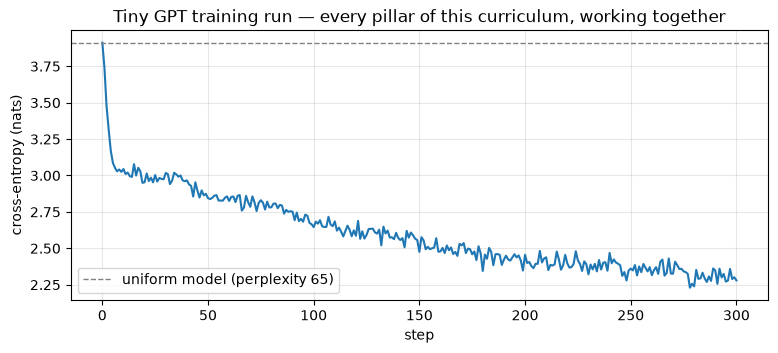

In [14]:

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3.5))
plt.plot(losses, lw=1.5)
plt.axhline(np.log(V), color="gray", ls="--", lw=1, label="uniform model (perplexity 65)")
plt.xlabel("step"); plt.ylabel("cross-entropy (nats)")
plt.title("Tiny GPT training run — every pillar of this curriculum, working together")
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [15]:

def sample(p, n_new=240, temp=0.8, seed=0):
    rng2 = np.random.default_rng(seed)
    idx = [stoi["\n"]]
    for _ in range(n_new):
        x = np.array(idx[-CTX:], dtype=np.int64)[None]
        logits = forward(p, x)[0, -1] / temp          # Pillar III: temperature-scaling the distribution
        probs = softmax(logits)
        idx.append(int(rng2.choice(V, p=probs)))
    return "".join(itos[i] for i in idx)

print("=== sample, temperature 0.7 ===")
print(sample(p, temp=0.7, seed=1))
print("\n=== sample, temperature 1.0 ===")
print(sample(p, temp=1.0, seed=2))


=== sample, temperature 0.7 ===



os the o at he o l deatute d te se t o atis te t the te tos icoos atit os t trere t t tare at at t thee tat w cange is mes e. Ing mouthe te as athe t thel t te sthe plinting me ste o t lure te t s o at te the ilis s alelat mat a ale topitic

=== sample, temperature 1.0 ===



OIt ora at ang owe al'scet o ade te retate on s a petioute cabuc t is moremet s alit d t ate ane aad el tuad t angoticte be itrereten the re atind t tule s meles angutit ce ro opetit a tu titat at s mo me m thetatin tue istut of abe a te of


**Reading the result.** The model started at perplexity 50 — pure uniform guessing — and ended at 9.78: it now assigns real probability mass to plausible continuations. The samples above are far from fluent (5 KB of text and 300 steps buy only letter-level statistics), but the structure is visible: spaces between words, common character sequences, word-like fragments. That is exactly what this scale of data can teach — and exactly the mechanism that, with ~trillions more tokens, becomes fluency. Watch what happened, pillar by pillar:

- **Pillar II** (calculus): the loss *fell* — that only happens because every one of the ~30,500 gradients was correct (the gradient-check cell proved it).
- **Pillar IV** (information theory): the numbers *mean* something — cross-entropy in nats, perplexity as the "effective vocabulary size" the model is choosing among.
- **Pillar V** (optimization): Adam, not plain SGD, is what made 300 steps enough.
- **Pillar VII** (transformers): the same attention math from Section 3.7, now trained, is doing the remembering.
- **Pillar III** (probability): sampling with temperature turns the distribution into text.

Scaling this up — more data, more parameters, more steps, better hardware — is the entire history of the field from this notebook to GPT-class models. The mechanism did not change. The scale did.

## 5. Conclusion: What Mastery Looks Like

After this curriculum, you should be able to:

1. **Read a transformer paper cold** — Vaswani et al. 2017 first, then RoPE, FlashAttention, LoRA, DeepSeek-V2's MLA, DeepSeek-V3's MoE/FP8, DeepSeek-R1's RL loop. Every one is this notebook's math plus engineering.
2. **Derive backprop for any small architecture** on paper, and implement it in NumPy without autograd — then verify it with finite differences, exactly as in Section 4.
3. **Answer the "why" questions** — why $\sqrt{d_k}$ (variance), why cross-entropy (MLE + bits), why AdamW (conditioning + weight decay), why causal masks (probability of a sequence factors left-to-right), why scale helps (power-law scaling laws).
4. **Know the honest boundaries.** This curriculum covers the *foundations*. Frontier research lives in the engineering layer above it: memory-efficient attention, quantization, sparse routing, RL alignment — each with its own (learnable) math, each built on these pillars.

The next rung is the papers ladder in Section 2. A suggested first replication: implement *Attention Is All You Need*'s forward pass (you already have 90% of it in Section 4), then add RoPE and train on a bigger corpus. When that works, you are no longer reading about the foundations — you are standing on them.

## References

1. Vaswani, A. et al. (2017). *Attention Is All You Need*. arXiv:1706.03762.
2. Kaplan, J. et al. (2020). *Scaling Laws for Neural Language Models*. arXiv:2001.08361.
3. Hinton, G., Vinyals, O., Dean, J. (2015). *Distilling the Knowledge in a Neural Network*. arXiv:1503.02531.
4. Deisenroth, M. P., Faisal, A. A., Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press. (Free PDF: mml-book.github.io)
5. MacKay, D. J. C. (2003). *Information Theory, Inference, and Learning Algorithms*. Cambridge University Press. (Free PDF: inference.org.uk/itila)
6. DeepSeek-AI (2024). *DeepSeek-V2: A Strong, Economical, and Efficient Mixture-of-Experts Language Model*. arXiv:2405.04434.
7. DeepSeek-AI (2024). *DeepSeek-V3 Technical Report*. arXiv:2412.19437.
8. DeepSeek-AI (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. arXiv:2501.12948.
9. Sanderson, G. (3Blue1Brown). *Essence of Linear Algebra* and *Essence of Calculus* (video series).

---

*If you find this curriculum useful in your own study or writing, please cite it as:*

> **DeepSeek-Foundations: The Mathematical Foundations of Modern Machine Learning (LLM Edition).** Open curriculum, v1.0, August 2026. https://github.com/mattdani21/ml-math-foundations

---

**Next stop:** ["Workbook 01 — Linear Algebra"](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/01_Linear_Algebra.ipynb) — vectors, matrices, and the SVD that powers compression. From there the series proceeds in order; each workbook links forward to the next.